In [148]:
from dlfs.layers import DenseLayer
from dlfs.activation import ReLU
from dlfs.loss import MSE_Loss
from dlfs.optimizers import Optimizer_SGD, Optimizer_Adam
from dlfs.model import SequentialModel

from viz_helpers import *

# Dense Layer visualisation for regression

- this notebook aims to visualize 1D, 2D, 3D linear transformations (by Dense Layers) and activation functions applied to regression data 

# Different datasets for visualisation

In [ ]:
from sklearn.datasets import make_regression

def make_sine(n_samples=100, n_features=1, noise=0.3):
    if n_features == 2:
        X = np.random.uniform(-5, 5, size=(n_samples, 2))
        x1, x2 = X[:, 0], X[:, 1]
        f = lambda x1, x2: np.sin(x1) * np.cos(x2)
        y = f(x1, x2) + np.random.randn(len(X)) * noise
        return X, y, f        
    else:
        X = np.random.uniform(-5, 5, size=(n_samples, ))
        f = lambda x: 2*np.sin(x)
        y = f(X) + np.random.randn(n_samples) * noise
        return X, y, f

def make_cubic(n_samples=50, n_features=1, noise=5):
    if n_features == 2:
        X = np.random.uniform(-5, 5, size=(n_samples, 2))
        x1, x2 = X[:, 0], X[:, 1]
        f = lambda x1, x2: (x1**3 - 2*x1**2 + 3*x1) * np.cos(x2) + 0.5*x2**2
        y = f(x1, x2) + np.random.randn(len(X)) * noise
        return X, y, f
    else:
        f = lambda x: X**3-2*X**2+3*x+1
        X = np.random.uniform(-5, 5, size=(n_samples, ))
        y = f(X) + np.random.randn(n_samples) * noise
        return X, y, None

def make_logarithm(n_samples=100, n_features=1, noise=0.1):
    if n_features == 2:
        X = np.empty((0, 2))

        while len(X) < n_samples:
            candidates = np.random.uniform(-1, 10, size=(n_samples, 2))
            valid = candidates[:, 0] * candidates[:, 1] + 1 > 0
            X = np.vstack([X, candidates[valid]])

        X = X[:n_samples]
        x1, x2 = X[:, 0], X[:, 1]
        f = lambda x1, x2: np.log(x1 * x2 + 1)
        y = f(x1, x2) + np.random.randn(n_samples) * noise
        return X, y, f
    else:
        X = np.random.uniform(-1, 10, size=(n_samples, ))
        f = lambda x: np.log(x + 1)
        y = f(X) + np.random.randn(n_samples) * noise
        return X, y, f

datasets = {
    "simple": make_regression(n_samples=200, n_features=1, noise=20),
    "sine": make_sine,
    "cubic": make_cubic,
    "logarithm": make_logarithm
}

def create_meshgrid(X, resolution):
    x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), resolution)
    x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), resolution)
    X1, X2 = np.meshgrid(x1, x2)
    return X1, X2

def plot_3d_regression(X, y, f, title, resolution=80):

    X1, X2 = create_meshgrid(X, resolution)

    with np.errstate(invalid='ignore', divide='ignore'):
        Z = f(X1, X2)
    Z[~np.isfinite(Z)] = np.nan

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=X[:, 0], y=X[:, 1], z=y, mode='markers',
        marker=dict(size=3, color=y, colorscale='Viridis', opacity=0.7,
                    colorbar=dict(title='y')),
        name='Data',
        hovertemplate='x1:%{x:.2f}<br>x2:%{y:.2f}<br>y:%{z:.2f}<extra></extra>'
    ))
    fig.add_trace(go.Surface(
        x=X1, y=X2, z=Z, opacity=0.45, colorscale='Blues',
        showscale=False, name='Model',
        hovertemplate='x1:%{x:.2f}<br>x2:%{y:.2f}<br>ŷ:%{z:.2f}<extra></extra>'
    ))
    fig.update_layout(
        title=title, height=700,
        scene=dict(xaxis_title='x1', yaxis_title='x2', zaxis_title='y',
                   camera=dict(eye=dict(x=1.6, y=1.6, z=1.0))),
        updatemenus=[
            dict(
                type="buttons",
                direction="right",
                buttons=[
                    dict(
                        label="Show f",
                        method="restyle",
                        args=[{"visible": [True]}, [1]]
                    ),
                    dict(
                        label="Hide f",
                        method="restyle",
                        args=[{"visible": [False]}, [1]]
                    ),
                ],
            )
        ]
    )

    return fig

# Simple regression dataset

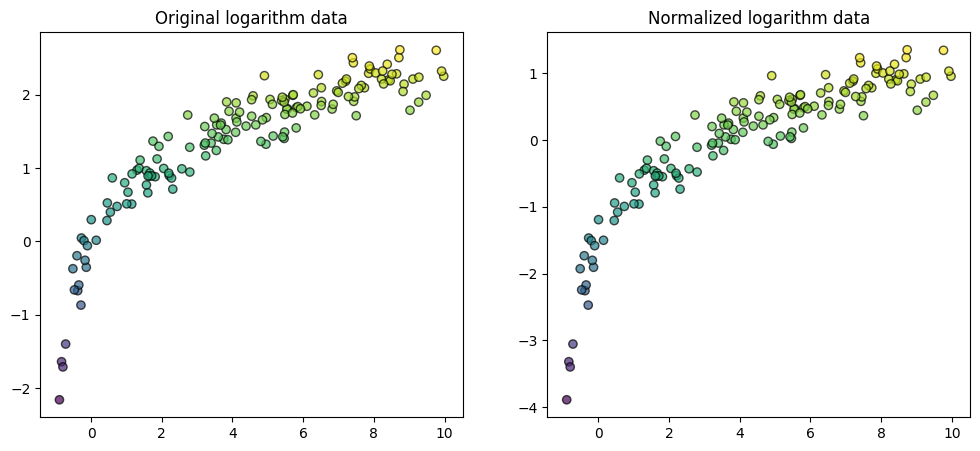

In [158]:
from sklearn.preprocessing import StandardScaler

dataset = "logarithm"
n_samples = 150
n_features = 1
noise = 0.2

X, y, true_f = datasets[dataset](n_samples, n_features, noise)

if n_features == 1:

    X = X.reshape(-1, 1)

    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    ax[0].scatter(X, y, c=y, edgecolors="k", alpha=0.7)
    ax[0].set_title(f"Original {dataset} data")
    ax[1].scatter(X, y_scaled, c=y_scaled, edgecolors="k", alpha=0.7)
    ax[1].set_title(f"Normalized {dataset} data")

    plt.show()

elif n_features == 2:
    title = f"{str.capitalize(dataset)} data"
    fig = plot_3d_regression(X, y, true_f, title)
    fig.show()

# Training regression model

In [ ]:
layers = [
    DenseLayer(n_features, 3), 
    ReLU(),
    DenseLayer(3, 2),
    ReLU(),
    DenseLayer(2, 1)
]

model = SequentialModel(
    layers=layers, 
    loss_function=MSE_Loss(), 
    optimizer=Optimizer_SGD(learning_rate=1e-3, momentum=0.3, decay=0.)
)

model.train(X, y_scaled, print_every=500, epochs=1000)

===== EPOCH : 0 ===== LOSS : 0.93365 =====
===== EPOCH : 500 ===== LOSS : 0.02907 =====
===== EPOCH : 1000 ===== LOSS : 0.01455 =====


# Extract each layer's output

In [8]:
model.forward(X)

Z1 = model.wrapper.layers[0].output.copy() # first dense layer
A1 = model.wrapper.layers[1].output.copy() # first dense + actiavtion
Z2 = model.wrapper.layers[2].output.copy() # second dense layer
A2 = model.wrapper.layers[3].output.copy() # second dense layer + activation
Z3 = model.wrapper.layers[4].output.copy() # third dense layer, final output

input_dim = model.wrapper.layers[0].weights.shape[0]
layer1_dim = Z1.shape[1]
layer2_dim = Z2.shape[1]
layer3_dim = Z3.shape[1]

# Plotting original 1D data on a number line

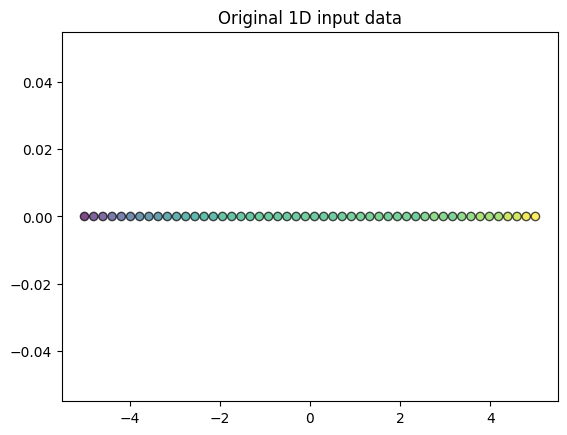

In [9]:
plot_1d_regression_output(X, y, "Original 1D input data")

# Plotting first linear transformation

In [10]:
title = f"{input_dim}D → {layer1_dim}D using first Dense Layer"
plot_3d_regression_output(Z1, y_scaled.reshape(-1), title)

# Plotting first linear transformation and first activation

In [21]:
title = f"1D → {layer1_dim}D using first Dense Layer + Activation"
plot_3d_regression_output(A1, y_scaled.reshape(-1), title)

# Plotting second linear transformation

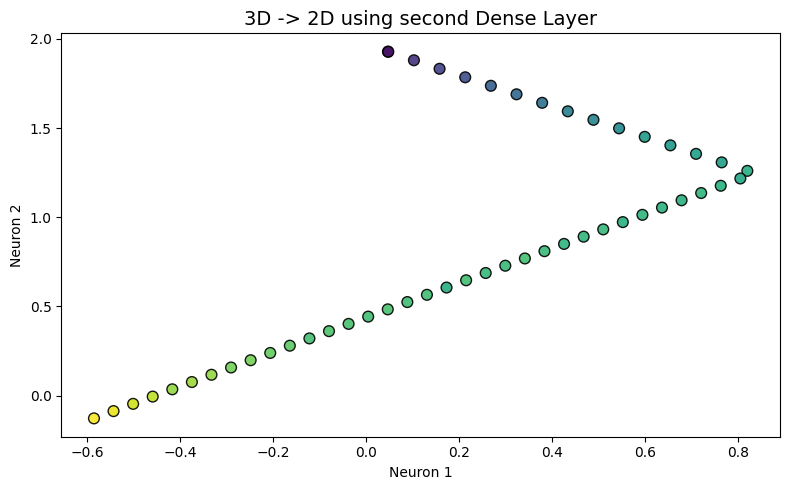

In [9]:
plot_2d_regression_output(Z2, y_scaled.reshape(-1), "3D -> 2D using second Dense Layer")

# Plotting second linear transformation and second activation

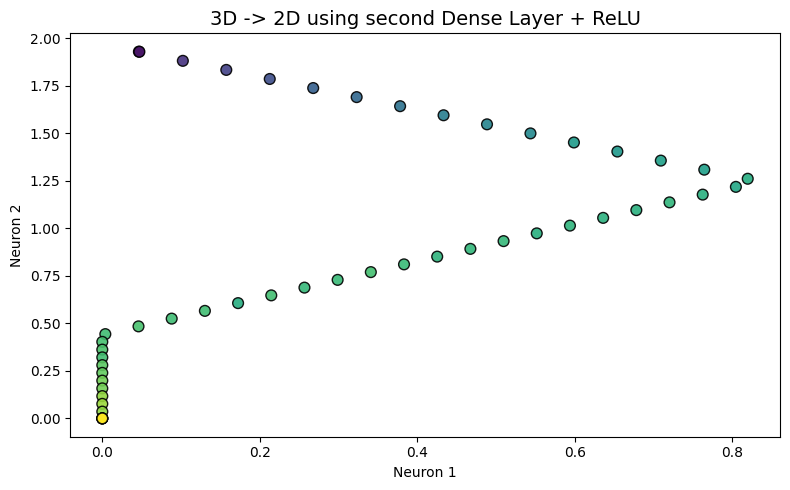

In [10]:
plot_2d_regression_output(A2, y_scaled.reshape(-1), "3D -> 2D using second Dense Layer + ReLU")

# Plotting third linear transformation

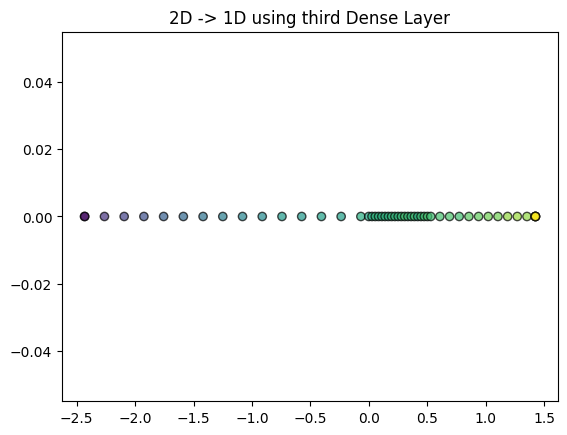

In [11]:
plot_1d_regression_output(Z3, y_scaled.reshape(-1), "2D -> 1D using third Dense Layer")

# Preprocess input data for final plot

In [12]:
X_range = np.linspace(X.min(), X.max(), 50).reshape(-1, 1)
y_pred_scaled = model.predict(X_range)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

sorted_X = np.sort(X)
y_pred_sorted_scaled = model.predict(sorted_X)
y_pred_sorted = scaler_y.inverse_transform(y_pred_sorted_scaled)

# Visualize network output

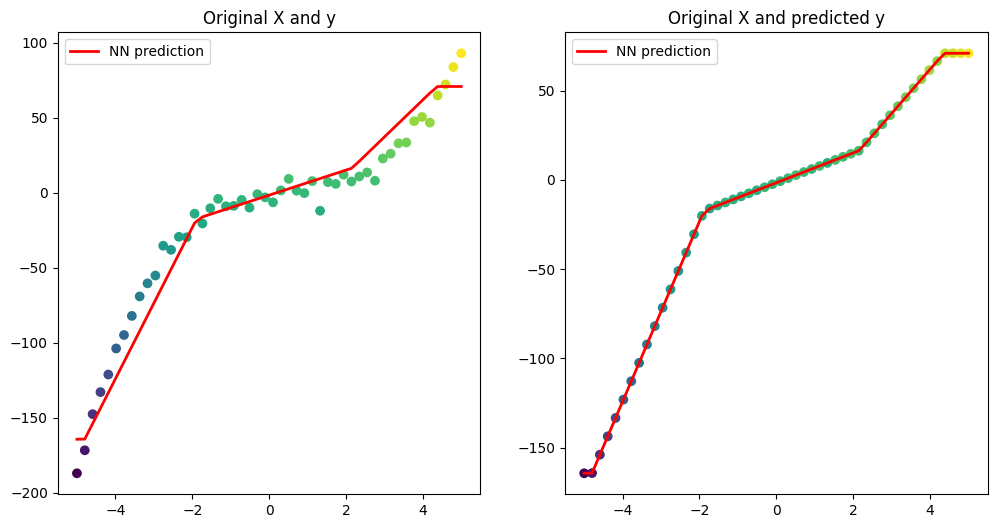

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
ax = ax.flatten()

ax[0].scatter(X, y, c=y)
ax[0].set_title("Original X and y")
ax[0].plot(X_range, y_pred, color="red", label="NN prediction", linewidth=2)

ax[1].scatter(sorted_X, y_pred_sorted, c=y_scaled)
ax[1].plot(X_range, y_pred, color="red", label="NN prediction", linewidth=2)
ax[1].set_title("Original X and predicted y")

ax[0].legend()
ax[1].legend()

plt.show()

In [12]:
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# 1. Generate & fit
X, y = make_regression(n_samples=200, n_features=2, noise=15, random_state=42)
model = LinearRegression().fit(X, y)

# 2. Build prediction meshgrid
resolution = 50
x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), resolution)
x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), resolution)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
Z_pred = model.predict(np.c_[X1_grid.ravel(), X2_grid.ravel()]).reshape(X1_grid.shape)

# 3. Create interactive figure
fig = go.Figure()

# Scatter: actual data points
fig.add_trace(go.Scatter3d(
    x=X[:, 0], y=X[:, 1], z=y,
    mode='markers',
    marker=dict(size=4, color=y, colorscale='Viridis', opacity=0.8,
                colorbar=dict(title='y value')),
    name='Data Points',
    hovertemplate='x1: %{x:.2f}<br>x2: %{y:.2f}<br>y: %{z:.2f}<extra></extra>'
))

# Surface: model predictions
fig.add_trace(go.Surface(
    x=X1_grid, y=X2_grid, z=Z_pred,
    opacity=0.4,
    colorscale='Blues',
    showscale=False,          # avoid duplicate colorbar
    name='Model Surface',
    hovertemplate='x1: %{x:.2f}<br>x2: %{y:.2f}<br>ŷ: %{z:.2f}<extra></extra>'
))

# Layout
fig.update_layout(
    title='2D Regression: Data vs Model Prediction Surface',
    scene=dict(
        xaxis_title='Feature 1',
        yaxis_title='Feature 2',
        zaxis_title='Target (y)',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))  # better default angle
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    height=700
)

fig.show()

In [14]:
import numpy as np
import plotly.graph_objects as go
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ============================================================
# HELPER: Reusable 3D regression plotter
# ============================================================
def plot_3d_regression(X, y, model, title, resolution=80):
    """Fit model (if not already fitted) and render interactive 3D surface + scatter."""
    # Fit only if needed (allows passing pre-fitted models)
    if not hasattr(model, 'predict') or not hasattr(model, '_is_fitted'):
        try:
            model.fit(X, y)
        except Exception:
            pass  # assume already fitted

    # Meshgrid
    x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), resolution)
    x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), resolution)
    X1, X2 = np.meshgrid(x1, x2)
    Z = model.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(X1.shape)

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=X[:, 0], y=X[:, 1], z=y, mode='markers',
        marker=dict(size=3, color=y, colorscale='Viridis', opacity=0.7,
                    colorbar=dict(title='y')),
        name='Data',
        hovertemplate='x1:%{x:.2f}<br>x2:%{y:.2f}<br>y:%{z:.2f}<extra></extra>'
    ))
    fig.add_trace(go.Surface(
        x=X1, y=X2, z=Z, opacity=0.45, colorscale='Blues',
        showscale=False, name='Model',
        hovertemplate='x1:%{x:.2f}<br>x2:%{y:.2f}<br>ŷ:%{z:.2f}<extra></extra>'
    ))
    fig.update_layout(
        title=title, height=700,
        scene=dict(xaxis_title='x1', yaxis_title='x2', zaxis_title='y',
                   camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)))
    )
    return fig


# ============================================================
# SINE DATASET
# ============================================================
np.random.seed(42)
n = 300
"""X_sin = np.random.uniform(-3, 3, size=(n, 2))
y_sin = np.sin(X_sin[:, 0]) * np.cos(X_sin[:, 1]) + np.random.normal(0, 0.1, n)

# LinearRegression would produce a flat plane here — use MLP instead
sin_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=2000, random_state=42))
])
sin_model.fit(X_sin, y_sin)

fig_sin = plot_3d_regression(X_sin, y_sin, sin_model,
                             'Sine Surface: y = sin(x₁)·cos(x₂)', resolution=100)
fig_sin.show()"""


# ============================================================
# LOGARITHMIC DATASET
# ============================================================
# Log requires strictly positive inputs
X_log = np.random.uniform(0.5, 5.0, size=(n, 2))
y_log = np.log(X_log[:, 0] * X_log[:, 1] + 1) + np.random.normal(0, 0.05, n)

log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=2000, random_state=42))
])
log_model.fit(X_log, y_log)

fig_log = plot_3d_regression(X_log, y_log, log_model,
                             'Log Surface: y = ln(x₁·x₂ + 1)', resolution=100)
fig_log.show()